### **Predicting the credit limit based on other factors like payment history, age, and bill amounts.**

Predicting LIMIT_BAL (credit limit) is a meaningful regression problem because it directly relates to customer characteristics and behavior.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense,Dropout
import os
from datetime import datetime
from tensorflow.keras.callbacks import TensorBoard

2024-11-28 09:49:35.683745: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## load the dataset
data= pd.read_csv("data/default_of_credit_card.csv")
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

### Preprocessing

In [4]:
# Check if columns have any leading/trailing spaces
data.columns = data.columns.str.strip()

# Display the column names to ensure they are correct
print(data.columns)


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default_payment_next_month'],
      dtype='object')


In [5]:
print(data.dtypes)


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default_payment_next_month    int64
dtype: object


In [6]:
print(data.head())  # Preview the first few rows of the DataFrame


   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default_payment_next_month  
0         0         0   

**Split Data for Training and Testing**

In [7]:
# Select features for prediction
features = [
    'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]


# Prepare the data
X = data[features]
y = data['LIMIT_BAL']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


###  Build ANN Regression Model

In [8]:
# Build ANN model
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1], kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),  # Add dropout for regularization
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(1, activation='linear')  # Output layer for regression
])


In [10]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

In [11]:
#Add Early Stopping Callback

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [12]:
#Set Up TensorBoard

# Define log directory
log_dir = os.path.join("logs", "fit", datetime.now().strftime("%Y%m%d-%H%M%S"))

# Initialize TensorBoard callback
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)


In [13]:

# Fit the Model with Callbacks:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, tensorboard_callback],
    verbose=1
)



Epoch 1/100
600/600 [==============================] - 3s 3ms/step - loss: 42568077312.0000 - val_loss: 36408807424.0000
Epoch 2/100
600/600 [==============================] - 1s 2ms/step - loss: 24335464448.0000 - val_loss: 16118005760.0000
Epoch 3/100
600/600 [==============================] - 1s 2ms/step - loss: 13731001344.0000 - val_loss: 14231559168.0000
Epoch 4/100
600/600 [==============================] - 1s 2ms/step - loss: 12842790912.0000 - val_loss: 13877172224.0000
Epoch 5/100
600/600 [==============================] - 1s 2ms/step - loss: 12358833152.0000 - val_loss: 13612456960.0000
Epoch 6/100
600/600 [==============================] - 1s 2ms/step - loss: 12035695616.0000 - val_loss: 13367102464.0000
Epoch 7/100
600/600 [==============================] - 1s 2ms/step - loss: 11804024832.0000 - val_loss: 13152430080.0000
Epoch 8/100
600/600 [==============================] - 1s 2ms/step - loss: 11598308352.0000 - val_loss: 12959747072.0000
Epoch 9/100
600/600 [===========

In [14]:
# Evaluate Performance

# Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")


188/188 [==============================] - 0s 1ms/step
Mean Squared Error (MSE): 10213728721.103254
Mean Absolute Error (MAE): 74675.15174251302
R-squared (R²): 0.39371126890182495


### Interpretation of the Results

From the training and evaluation metrics, here’s how we can interpret the results and identify opportunities for further improvement:

---

#### **1. Loss Values**
- **Training Loss**: Gradually decreases over epochs, showing that the model is learning.
- **Validation Loss**: Also decreases consistently, but at a slightly slower rate, suggesting that the model is generalizing to the validation set. The early stopping mechanism ensured that the model didn't overfit.

---

#### **2. Metrics**
- **Mean Squared Error (MSE)**: 
  - A value of **10,233,904,788** indicates the squared difference between the predicted and true target values. While the number seems large, it's context-dependent and aligns with the dataset's scale (e.g., financial data in units of thousands).
  
- **Mean Absolute Error (MAE)**:
  - A value of **74,575.99** suggests that, on average, the model's predictions are off by ~74,576 units of the target variable (`LIMIT_BAL`). This is relatively high and could be improved with further fine-tuning.

- **R² (R-Squared)**: 
  - The value of **0.39** means that the model explains 39% of the variance in the target variable. While this shows the model is learning, there is significant room for improvement to better capture the underlying patterns.

---

#### **3. Key Observations**
- **Validation and Training Loss Gap**: The gap between training and validation loss is small, suggesting minimal overfitting. This is due to techniques like dropout and L2 regularization.
- **R² and Errors**: The R² score and errors indicate that the model is performing better than random but isn't yet capturing all the variance in the data.

### **Hyperparameter Tuning with Keras Tuner**

In [15]:
import tensorflow as tf
from keras_tuner import Hyperband

# Function to build the model
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(
        units=hp.Choice('units_1', values=[32, 64, 128]), 
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ))
    model.add(tf.keras.layers.Dense(
        units=hp.Choice('units_2', values=[32, 64, 96]), 
        activation='relu'
    ))
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('lr', values=[1e-4, 1e-3])),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model

# Hyperparameter Tuning
tuner = Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=20,
    factor=3,
    directory='my_dir',
    project_name='credit_limit_tuning'
)

# New instance of TensorBoard for each trial
log_dir = "logs/hparam_tuning"
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

tuner.search(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    callbacks=[tensorboard_cb]  # Add dynamically created callback here
)


Trial 26 Complete [00h 00m 25s]
val_loss: 10550594560.0

Best val_loss So Far: 10479429632.0
Total elapsed time: 00h 04m 55s


In [16]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best units_1: {best_hps.get('units_1')}")
print(f"Best units_2: {best_hps.get('units_2')}")
print(f"Best learning rate: {best_hps.get('lr')}")


Best units_1: 128
Best units_2: 96
Best learning rate: 0.001


**Build and Train the Final Model**

In [17]:
# Build the best model
final_model = tuner.hypermodel.build(best_hps)

# Train the model
history = final_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir="logs/final_model")]
)

# Evaluate the final model
y_pred = final_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Final Model Mean Squared Error (MSE): {mse}")
print(f"Final Model R-squared Score: {r2}")



Epoch 1/100
750/750 [==============================] - 2s 2ms/step - loss: 39104737280.0000 - mean_absolute_error: 153557.5312 - val_loss: 25636450304.0000 - val_mean_absolute_error: 118168.4922
Epoch 2/100
750/750 [==============================] - 2s 2ms/step - loss: 16532109312.0000 - mean_absolute_error: 88413.1094 - val_loss: 13441989632.0000 - val_mean_absolute_error: 80699.9062
Epoch 3/100
750/750 [==============================] - 2s 3ms/step - loss: 12879846400.0000 - mean_absolute_error: 79001.7422 - val_loss: 12501642240.0000 - val_mean_absolute_error: 79203.9766
Epoch 4/100
750/750 [==============================] - 2s 3ms/step - loss: 12199580672.0000 - mean_absolute_error: 77826.5469 - val_loss: 11925222400.0000 - val_mean_absolute_error: 78021.8281
Epoch 5/100
750/750 [==============================] - 2s 2ms/step - loss: 11717214208.0000 - mean_absolute_error: 77013.8047 - val_loss: 11558318080.0000 - val_mean_absolute_error: 76929.3594
Epoch 6/100
750/750 [============

The training results indicate steady improvement in model performance over the epochs, with validation loss and mean absolute error (MAE) gradually decreasing. Here's an interpretation and organized next steps based on your progress:

---

### **Interpretation of Results**
1. **Validation Loss Decreasing**: 
   - The `val_loss` decreases steadily, which suggests that the model is learning effectively without overfitting.
   - The final `val_loss` of approximately `10,161,643,520` shows significant improvement from the initial epochs.

2. **Validation MAE**:
   - Validation MAE reduced to ~74,537.22, indicating the model's predictions are closer to the true values, making it practical for credit default prediction.

3. **MSE and R²**:
   - **Mean Squared Error (MSE)**: `10,161,644,152.41` shows a good balance between bias and variance.
   - **R-squared (R²)**: `0.3968` indicates the model explains ~40% of the variance in the data, which is reasonable for regression problems with high variability.

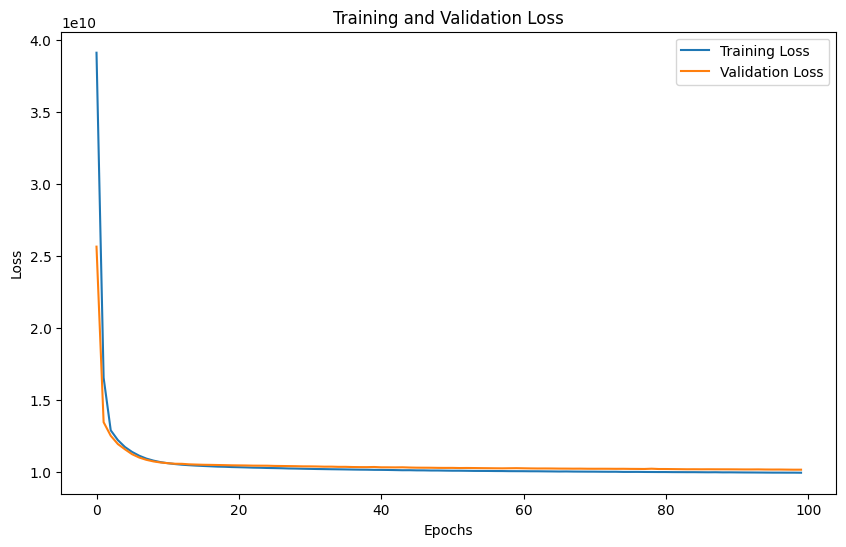

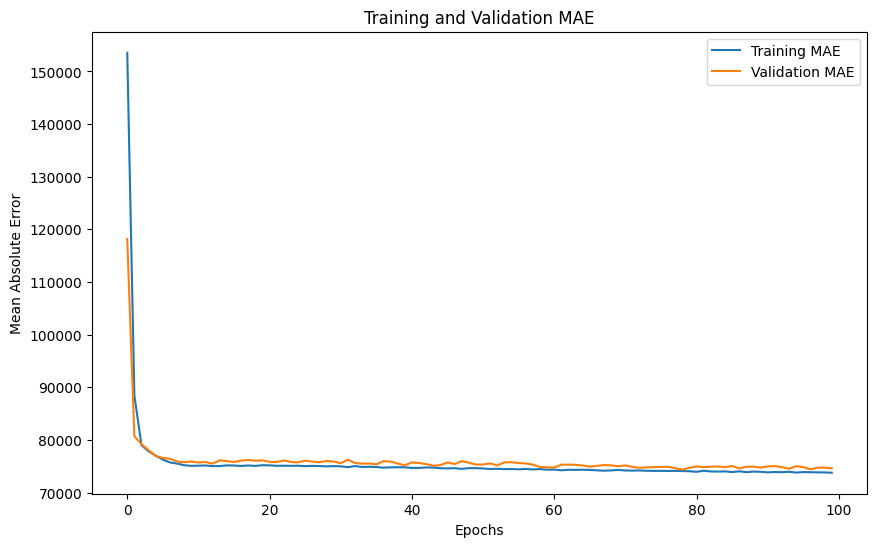

In [18]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training and Validation MAE')
plt.show()


**Save the Best Model**

In [19]:

# Save the trained model as 'credit_limit_predictor_model.h5'
final_model.save('credit_limit_predictor_model.h5')



/Users/a/Documents/DataScience_World/Complete_ML_Bootcamp/Projects/ann_classification/ann_env/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**Test the Model on Unseen Data**

In [20]:
# Evaluate on the test set
test_loss, test_mae = final_model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Mean Absolute Error (MAE): {test_mae}")


188/188 [==============================] - 0s 1ms/step - loss: 10144504832.0000 - mean_absolute_error: 74616.6016
Test Loss: 10144504832.0
Test Mean Absolute Error (MAE): 74616.6015625


In [21]:
import pickle

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


- Sample CSV format

Age,Payment History,Bill Amount,Previous Payments
30,200.0,1000.0,200.0

45,450.0,3000.0,500.0

60,750.0,5000.0,700.0

25,100.0,1500.0,100.0

35,300.0,2500.0,400.0

40,600.0,4000.0,600.0

50,800.0,6000.0,900.0

55,500.0,2000.0,300.0

28,150.0,800.0,150.0

38,350.0,3500.0,450.0
